# Projet ML – Prédiction du Prix de Vente d'une Voiture d'Occasion


RHAFIR Youssef (MSDE7)  


---
## 1. Compréhension de la problématique

### 1.1 Contexte

Le dataset utilisé recense des annonces de voitures d'occasion avec leurs caractéristiques techniques et commerciales. L'objectif est d'estimer automatiquement le prix de revente d'un véhicule à partir de ses caractéristiques, ce qui représente un problème concret et utile aussi bien pour les acheteurs que pour les vendeurs.

### 1.2 Traduction en tâche ML

Il s'agit d'une **régression supervisée** : on cherche à prédire une valeur numérique continue (le prix en euros) à partir d'un ensemble de variables explicatives. La variable cible est price.

Les features disponibles couvrent les caractéristiques techniques (puissance, kilométrage, type de carburant, boîte de vitesses) et commerciales (marque, modèle, type de carrosserie, historique de dommages).

### 1.3 État de l'art

Plusieurs familles d'algorithmes ont été utilisées dans la littérature pour ce type de problème :

**Modèles linéaires** (Ridge, Lasso, ElasticNet) : simples et interprétables, mais limités face aux relations non-linéaires entre les variables. Ils servent ici de référence (baseline).

**Arbres de décision et méthodes d'ensemble** (Random Forest, Extra Trees) : bien adaptés aux données tabulaires hétérogènes, robustes aux outliers résiduels.

**Gradient Boosting** (XGBoost, LightGBM, GradientBoosting) : état de l'art sur les données tabulaires. Ces méthodes construisent des modèles de manière additive en corrigeant les erreurs à chaque étape. Elles donnent généralement les meilleurs résultats sur ce type de problème (Gegic et al. 2019, Bansal 2022).

**KNN, AdaBoost** : complémentaires, permettent d'explorer d'autres approches.

Références :
- Gegic et al. (2019). Car price prediction using machine learning techniques. TEM Journal, 8(1), 113-118.
- Bansal M. (2022). A comparative study of ML algorithms for used car price prediction. IEEE ICRITO.
- Chen T. & Guestrin C. (2016). XGBoost: A scalable tree boosting system. ACM KDD.
- Ke G. et al. (2017). LightGBM: A highly efficient gradient boosting decision tree. NIPS.

---
## 2. Chargement des données et Analyse Exploratoire (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

df = pd.read_csv('autos.csv')
print('Dimensions du dataset :', df.shape)
df.head()

Dimensions du dataset : (371528, 21)


,index,dateCrawled,name,seller,offerType,price,abtest,vehicleType,yearOfRegistration,gearbox,...,model,kilometer,monthOfRegistration,fuelType,brand,notRepairedDamage,dateCreated,nrOfPictures,postalCode,lastSeen
0,0,2016-03-24 11:52:17,Golf_3_1.6,privat,Angebot,480,test,NaN,1993,manuell,...,golf,150000,0,benzin,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,1,2016-03-24 10:58:45,A5_Sportback_2.7_Tdi,privat,Angebot,18300,test,coupe,2011,manuell,...,NaN,125000,5,diesel,audi,ja,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2,2016-03-14 12:52:21,"Jeep_Grand_Cherokee_""Overland""",privat,Angebot,9800,test,suv,2004,automatik,...,grand,125000,8,diesel,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,3,2016-03-17 16:54:04,GOLF_4_1_4__3TÜRER,privat,Angebot,1500,test,kleinwagen,2001,manuell,...,golf,150000,6,benzin,volkswagen,nein,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,4,2016-03-31 17:25:20,Skoda_Fabia_1.4_TDI_PD_Classic,privat,Angebot,3600,test,kleinwagen,2008,manuell,...,fabia,90000,7,diesel,skoda,nein,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371528 entries, 0 to 371527
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   index                371528 non-null  int64 
 1   dateCrawled          371528 non-null  object
 2   name                 371528 non-null  object
 3   seller               371528 non-null  object
 4   offerType            371528 non-null  object
 5   price                371528 non-null  int64 
 6   abtest               371528 non-null  object
 7   vehicleType          333659 non-null  object
 8   yearOfRegistration   371528 non-null  int64 
 9   gearbox              351319 non-null  object
 10  powerPS              371528 non-null  int64 
 11  model                351044 non-null  object
 12  kilometer            371528 non-null  int64 
 13  monthOfRegistration  371528 non-null  int64 
 14  fuelType             338142 non-null  object
 15  brand                371528 non-nu

In [3]:
df.describe()

,index,price,yearOfRegistration,powerPS,kilometer,monthOfRegistration,nrOfPictures,postalCode
count,371528.000000,3.715280e+05,371528.000000,371528.000000,371528.000000,371528.000000,371528.0,371528.00000
mean,185763.500000,1.729514e+04,2004.577997,115.549477,125618.688228,5.734445,0.0,50820.66764
std,107251.039743,3.587954e+06,92.866598,192.139578,40112.337051,3.712412,0.0,25799.08247
min,0.000000,0.000000e+00,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.00000
25%,92881.750000,1.150000e+03,1999.000000,70.000000,125000.000000,3.000000,0.0,30459.00000
50%,185763.500000,2.950000e+03,2003.000000,105.000000,150000.000000,6.000000,0.0,49610.00000
75%,278645.250000,7.200000e+03,2008.000000,150.000000,150000.000000,9.000000,0.0,71546.00000
max,371527.000000,2.147484e+09,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.00000


In [4]:
# Valeurs manquantes
missing = df.isnull().sum().sort_values(ascending=False)
pct = (missing / len(df) * 100).round(2)
pd.DataFrame({'nb_manquants': missing, 'pourcentage': pct})[missing > 0]

,nb_manquants,pourcentage
notRepairedDamage,72060,19.40
vehicleType,37869,10.19
fuelType,33386,8.99
model,20484,5.51
gearbox,20209,5.44


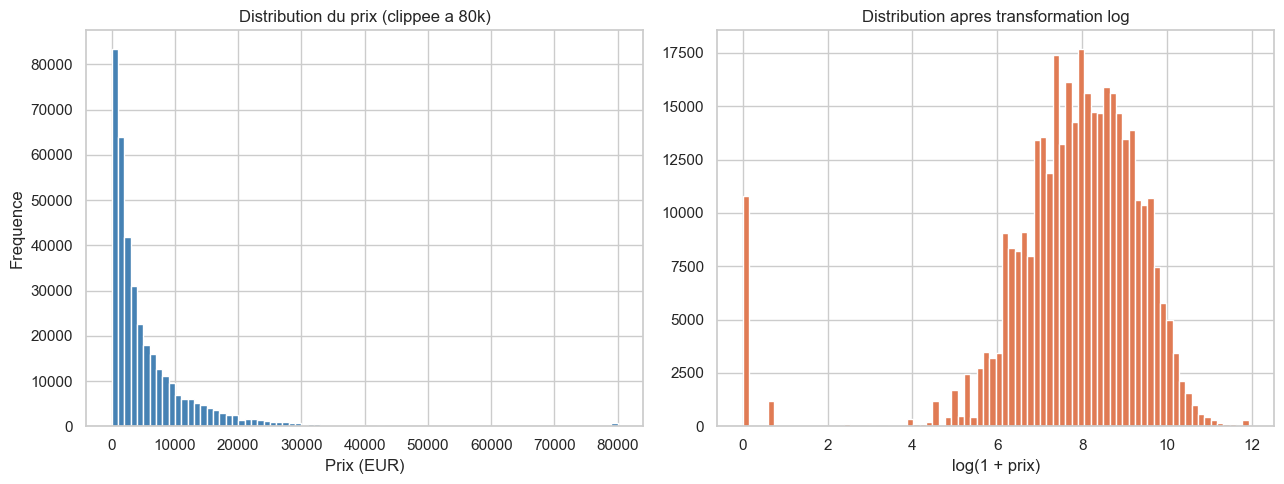

Prix = 0 : 10778 lignes
Prix > 150 000 : 232 lignes


In [5]:
# Distribution de la variable cible
# On constate une forte asymetrie a droite avec des valeurs extremes (prix = 0, ou > 500 000)
# Une transformation log sera appliquee lors du preprocessing

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['price'].clip(0, 80000), bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution du prix (clippee a 80k)')
axes[0].set_xlabel('Prix (EUR)')
axes[0].set_ylabel('Frequence')

axes[1].hist(np.log1p(df['price'].clip(0, 150000)), bins=80, color='#e07b54', edgecolor='white')
axes[1].set_title('Distribution apres transformation log')
axes[1].set_xlabel('log(1 + prix)')

plt.tight_layout()
plt.savefig('eda_prix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Prix = 0 :', (df['price'] == 0).sum(), 'lignes')
print('Prix > 150 000 :', (df['price'] > 150000).sum(), 'lignes')

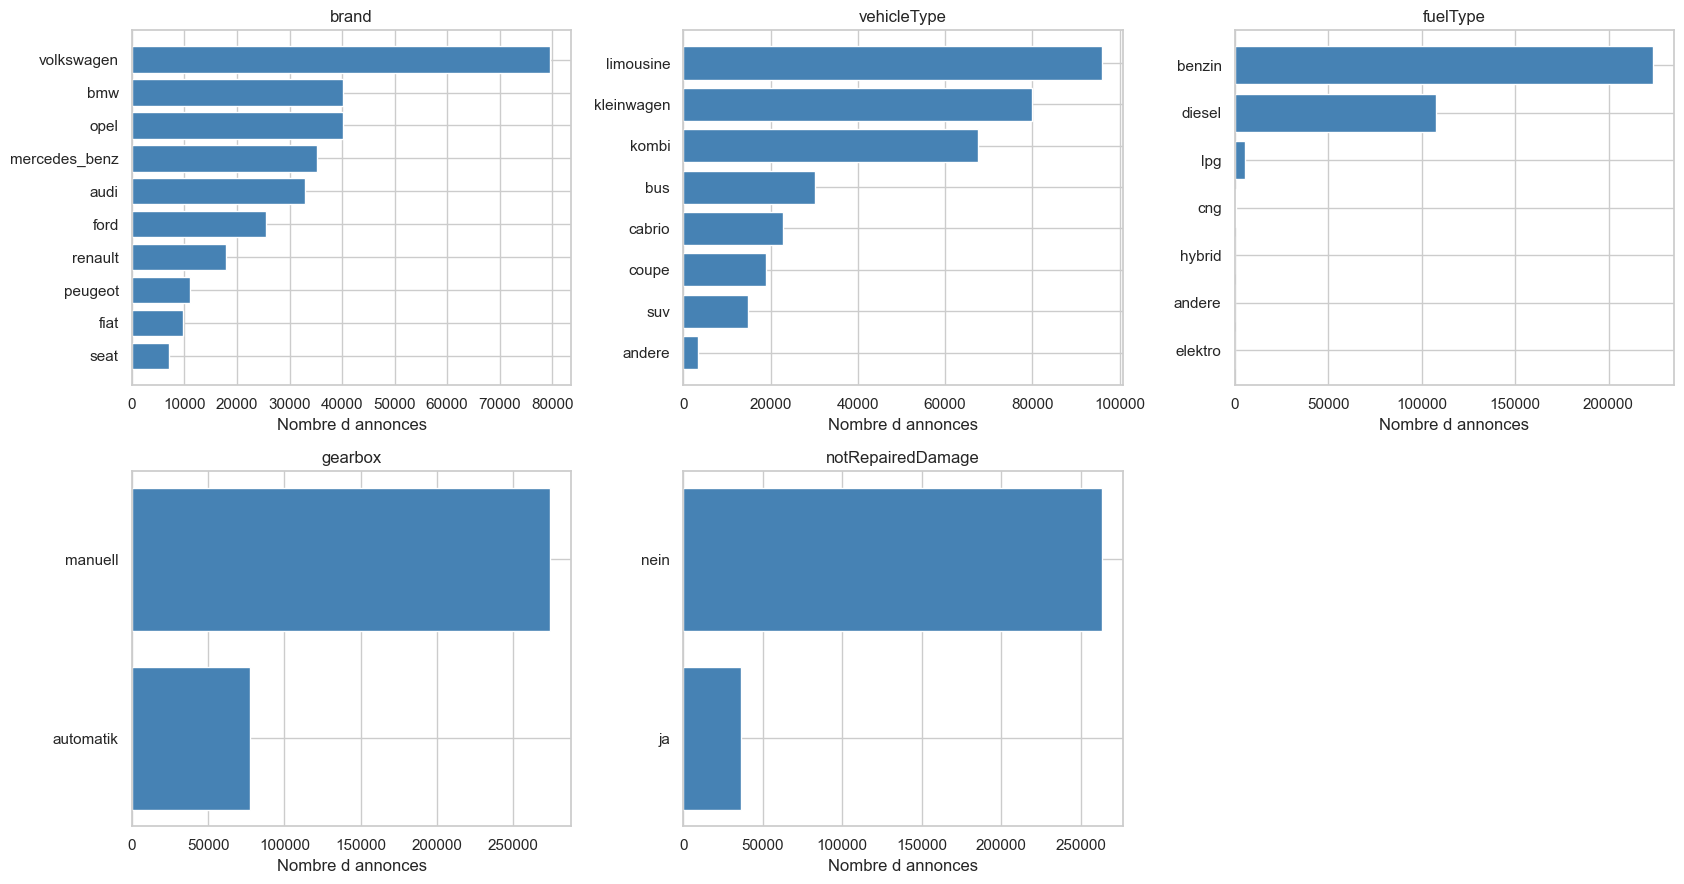

In [6]:
# Repartition des variables categorielles
variables_cat = ['brand', 'vehicleType', 'fuelType', 'gearbox', 'notRepairedDamage']

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

for i, col in enumerate(variables_cat):
    vc = df[col].value_counts().head(10)
    axes[i].barh(vc.index[::-1], vc.values[::-1], color='steelblue')
    axes[i].set_title(col)
    axes[i].set_xlabel('Nombre d annonces')

axes[5].axis('off')
plt.tight_layout()
plt.savefig('eda_categories.png', dpi=150, bbox_inches='tight')
plt.show()

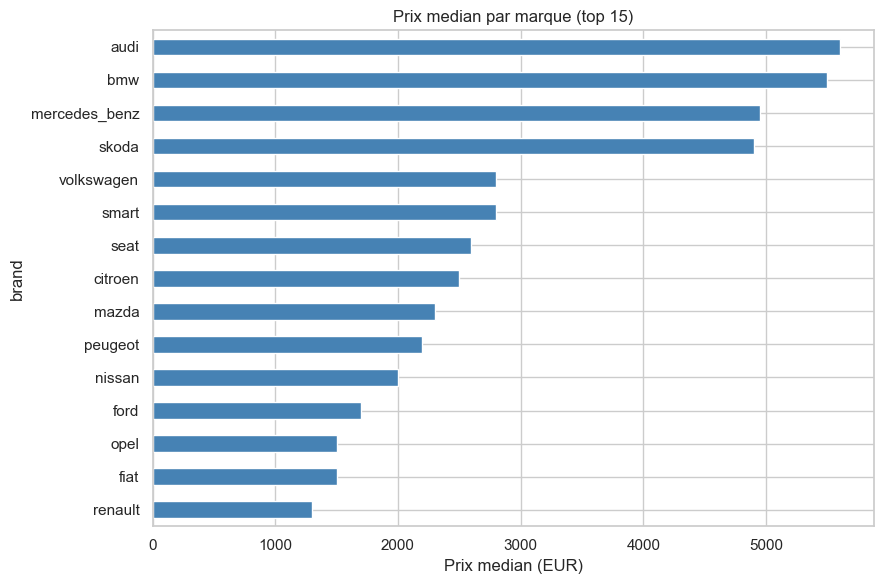

Les marques premium (BMW, Mercedes, Audi) affichent des prix medians nettement plus eleves.


In [7]:
# Prix median par marque (top 15 marques les plus representees)
top_marques = df['brand'].value_counts().head(15).index
prix_par_marque = df[df['brand'].isin(top_marques)].groupby('brand')['price'].median().sort_values()

plt.figure(figsize=(9, 6))
prix_par_marque.plot(kind='barh', color='steelblue')
plt.title('Prix median par marque (top 15)')
plt.xlabel('Prix median (EUR)')
plt.tight_layout()
plt.savefig('eda_marques.png', dpi=150, bbox_inches='tight')
plt.show()

print('Les marques premium (BMW, Mercedes, Audi) affichent des prix medians nettement plus eleves.')

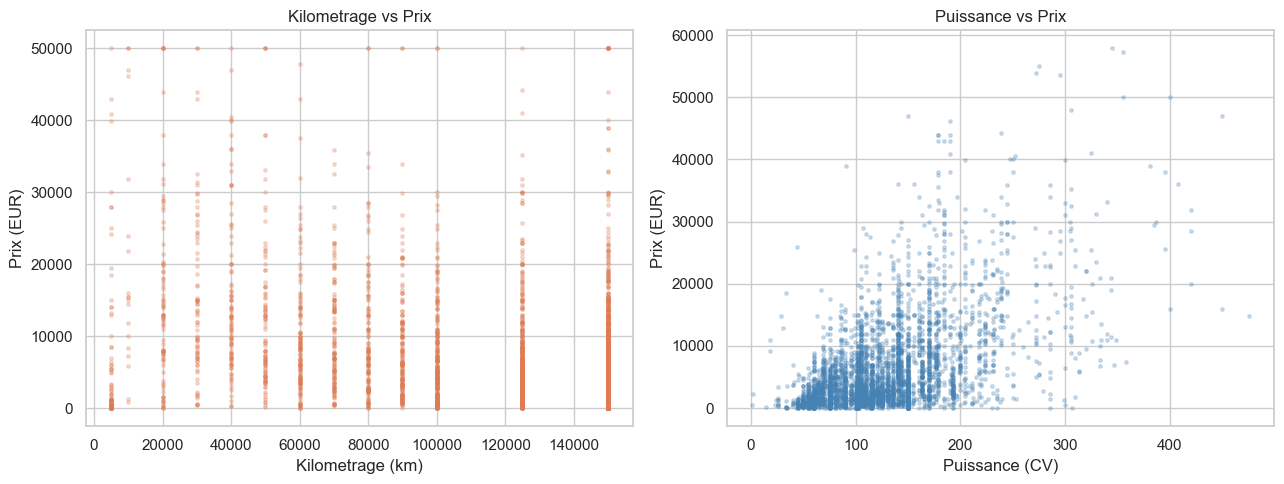

Kilometrage eleve => prix plus bas (depreciation par usage).
Puissance elevee => prix plus haut, surtout au-dela de 150 CV.


In [8]:
# Relation kilometrage / puissance avec le prix
echantillon = df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(echantillon['kilometer'],
                echantillon['price'].clip(0, 50000),
                alpha=0.25, s=6, color='#e07b54')
axes[0].set_title('Kilometrage vs Prix')
axes[0].set_xlabel('Kilometrage (km)')
axes[0].set_ylabel('Prix (EUR)')

masque = (echantillon['powerPS'] > 0) & (echantillon['powerPS'] < 500) & (echantillon['price'] < 60000)
axes[1].scatter(echantillon[masque]['powerPS'],
                echantillon[masque]['price'],
                alpha=0.25, s=6, color='steelblue')
axes[1].set_title('Puissance vs Prix')
axes[1].set_xlabel('Puissance (CV)')
axes[1].set_ylabel('Prix (EUR)')

plt.tight_layout()
plt.savefig('eda_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('Kilometrage eleve => prix plus bas (depreciation par usage).')
print('Puissance elevee => prix plus haut, surtout au-dela de 150 CV.')

In [9]:
# Verifier les valeurs aberrantes sur l annee d immatriculation
print('Repartition des annees extremes :')
print(df['yearOfRegistration'].value_counts().sort_index().head(8))
print('...')
print(df['yearOfRegistration'].value_counts().sort_index().tail(5))

# Annees avant 1980 ou apres 2016 sont des erreurs de saisie
print('\nNombre de lignes avec annee < 1980 :', (df['yearOfRegistration'] < 1980).sum())
print('Nombre de lignes avec annee > 2016 :', (df['yearOfRegistration'] > 2016).sum())

Repartition des annees extremes :
yearOfRegistration
1000    38
1001     1
1039     1
1111     4
1200     1
1234     4
1253     1
1255     1
Name: count, dtype: int64
...
yearOfRegistration
9000     5
9229     1
9450     1
9996     1
9999    27
Name: count, dtype: int64

Nombre de lignes avec annee < 1980 : 4119
Nombre de lignes avec annee > 2016 : 14680


### Bilan de l'EDA

Plusieurs points importants ont été identifiés lors de l'exploration :

La variable cible price présente une distribution très asymétrique avec des valeurs aberrantes importantes (prix nuls, prix > 150 000 EUR qui représentent des annonces erronées). Une transformation logarithmique sera appliquée pour normaliser la distribution.

Concernant les valeurs manquantes : notRepairedDamage manque dans 19% des cas, vehicleType dans 10%, fuelType dans 9%. Ces colonnes seront conservées et traitées par imputation.

L'année d'immatriculation contient des valeurs clairement erronées (années antérieures à 1900 ou futures), qui seront filtrées.

Les corrélations observées confirment l'intuition métier : kilométrage élevé => prix plus bas, puissance élevée => prix plus haut, marques premium => prix sensiblement plus élevés.

---
## 3. Pré-processing et Feature Engineering

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

data = df.copy()

# Suppression des colonnes qui ne sont pas des features utiles
# (metadonnees de crawling, colonnes constantes, identifiants)
a_supprimer = ['index', 'dateCrawled', 'dateCreated', 'lastSeen',
               'nrOfPictures', 'seller', 'offerType', 'abtest', 'name']
data.drop(columns=a_supprimer, inplace=True)

# Filtrage des lignes aberrantes
nb_avant = len(data)
data = data[
    (data['price'] >= 100) &
    (data['price'] <= 150000) &
    (data['yearOfRegistration'] >= 1980) &
    (data['yearOfRegistration'] <= 2016) &
    (data['powerPS'] > 0) &
    (data['powerPS'] <= 500) &
    (data['kilometer'] > 0)
]

print('Lignes supprimees (valeurs aberrantes) :', nb_avant - len(data))
print('Lignes restantes :', len(data))

Lignes supprimees (valeurs aberrantes) : 62970
Lignes restantes : 308558


In [11]:
# Feature engineering
# L age du vehicule est plus parlant que l annee brute et directement lie a la depreciation
data['age_vehicule'] = 2016 - data['yearOfRegistration']
data.drop(columns=['yearOfRegistration'], inplace=True)

# Transformation log de la cible (necessite par la distribution asymetrique)
data['log_price'] = np.log1p(data['price'])

print('Nouvelles dimensions :', data.shape)
print('\nQuelques statistiques sur le prix filtre :')
print(data['price'].describe().round(0))

Nouvelles dimensions : (308558, 13)

Quelques statistiques sur le prix filtre :
count    308558.0
mean       6141.0
std        7791.0
min         100.0
25%        1400.0
50%        3499.0
75%        7970.0
max      150000.0
Name: price, dtype: float64


In [12]:
# Definition des variables d entree
X = data.drop(columns=['price', 'log_price'])
y = data['log_price']

variables_num = ['kilometer', 'powerPS', 'monthOfRegistration', 'age_vehicule', 'postalCode']
variables_cat = ['vehicleType', 'gearbox', 'model', 'fuelType', 'brand', 'notRepairedDamage']

# Pipeline de preprocessing
# Les variables numeriques : imputation par la mediane + standardisation
# Les variables categorielles : imputation par le mode + encodage one-hot
prep_num = Pipeline([
    ('imputation', SimpleImputer(strategy='median')),
    ('normalisation', StandardScaler())
])

prep_cat = Pipeline([
    ('imputation', SimpleImputer(strategy='most_frequent')),
    ('encodage', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=50))
])

preprocessor = ColumnTransformer([
    ('numeriques', prep_num, variables_num),
    ('categorielles', prep_cat, variables_cat)
])

# Decoupage train/test 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train :', X_train.shape[0], 'lignes  |  Test :', X_test.shape[0], 'lignes')

Train : 246846 lignes  |  Test : 61712 lignes


---
## 4. Construction et évaluation de 12 modèles ML

On teste 12 algorithmes de régression couvrant plusieurs familles. Chaque modèle est intégré dans un Pipeline sklearn qui applique automatiquement le preprocessing avant l'entraînement.

In [13]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    ExtraTreesRegressor, AdaBoostRegressor
)
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time

def evaluer_modele(nom, pipeline, Xtr, ytr, Xte, yte):
    debut = time.time()
    pipeline.fit(Xtr, ytr)
    duree = round(time.time() - debut, 1)
    pred = np.expm1(pipeline.predict(Xte))
    reel = np.expm1(yte)
    return {
        'Modele' : nom,
        'R2'     : round(r2_score(reel, pred), 4),
        'RMSE'   : round(np.sqrt(mean_squared_error(reel, pred)), 0),
        'MAE'    : round(mean_absolute_error(reel, pred), 0),
        'Temps_s': duree
    }

algorithmes = {
    'Regression Lineaire'  : LinearRegression(),
    'Ridge'                : Ridge(alpha=1.0),
    'Lasso'                : Lasso(alpha=0.001),
    'ElasticNet'           : ElasticNet(alpha=0.001, l1_ratio=0.5),
    'Arbre de decision'    : DecisionTreeRegressor(random_state=42),
    'KNN'                  : KNeighborsRegressor(n_neighbors=10, n_jobs=-1),
    'AdaBoost'             : AdaBoostRegressor(n_estimators=100, random_state=42),
    'Extra Trees'          : ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'    : GradientBoostingRegressor(n_estimators=100, random_state=42),
    'Random Forest'        : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost'              : xgb.XGBRegressor(n_estimators=200, learning_rate=0.1,
                                               random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM'             : lgb.LGBMRegressor(n_estimators=200, learning_rate=0.1,
                                                random_state=42, n_jobs=-1, verbose=-1),
}

resultats  = []
pipelines  = {}

for nom, modele in algorithmes.items():
    print(nom, '...', end=' ', flush=True)
    pipe = Pipeline([('preprocessing', preprocessor), ('modele', modele)])
    res  = evaluer_modele(nom, pipe, X_train, y_train, X_test, y_test)
    resultats.append(res)
    pipelines[nom] = pipe
    print('R2 =', res['R2'], '  RMSE =', int(res['RMSE']), 'EUR')

df_resultats = pd.DataFrame(resultats).sort_values('R2', ascending=False).reset_index(drop=True)
print()
print(df_resultats.to_string(index=False))

Regression Lineaire ... R2 = 0.4266   RMSE = 5843 EUR
Ridge ... R2 = 0.4268   RMSE = 5841 EUR
Lasso ... R2 = 0.476   RMSE = 5585 EUR
ElasticNet ... R2 = 0.4733   RMSE = 5600 EUR
Arbre de decision ... R2 = 0.8223   RMSE = 3253 EUR
KNN ... R2 = 0.8389   RMSE = 3097 EUR
AdaBoost ... R2 = 0.1915   RMSE = 6938 EUR
Extra Trees ... R2 = 0.8984   RMSE = 2460 EUR
Gradient Boosting ... R2 = 0.7985   RMSE = 3463 EUR
Random Forest ... R2 = 0.8907   RMSE = 2551 EUR
XGBoost ... R2 = 0.8672   RMSE = 2812 EUR
LightGBM ... R2 = 0.8642   RMSE = 2843 EUR

             Modele     R2   RMSE    MAE  Temps_s
        Extra Trees 0.8984 2460.0 1053.0    166.2
      Random Forest 0.8907 2551.0 1091.0    133.5
            XGBoost 0.8672 2812.0 1293.0     14.7
           LightGBM 0.8642 2843.0 1302.0      4.9
                KNN 0.8389 3097.0 1493.0      2.0
  Arbre de decision 0.8223 3253.0 1382.0      8.4
  Gradient Boosting 0.7985 3463.0 1554.0    154.6
              Lasso 0.4760 5585.0 2175.0      5.3
       

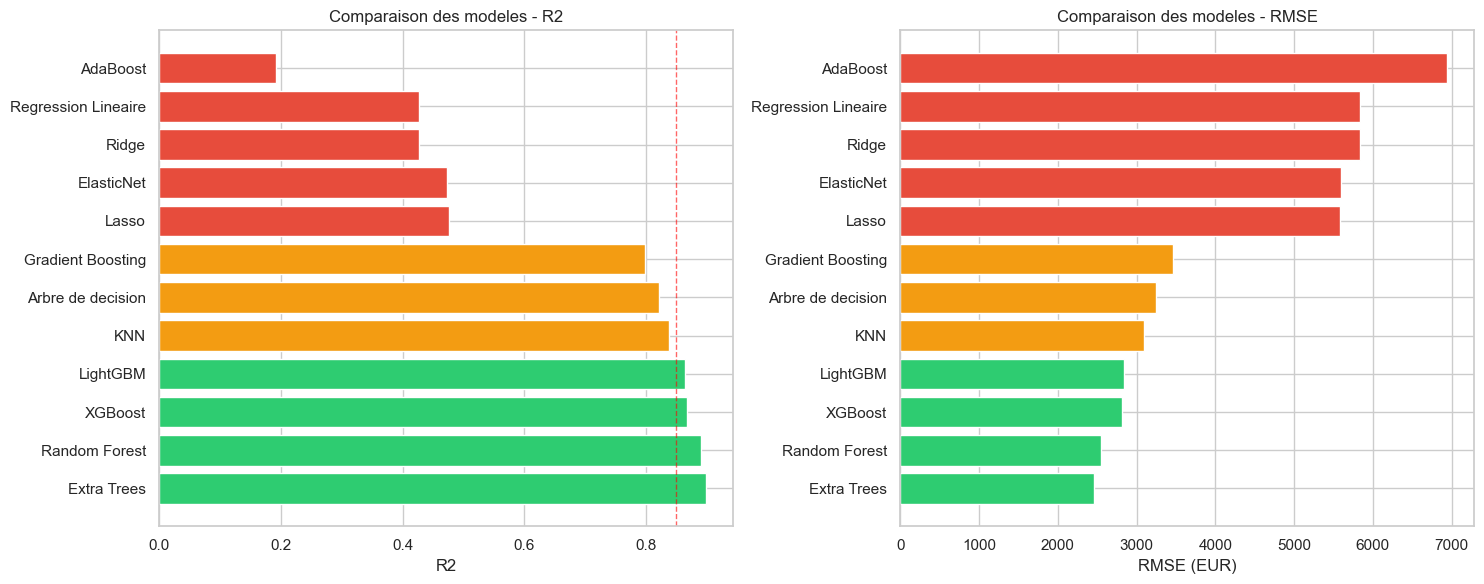

Les methodes de boosting (LightGBM, XGBoost) surpassent clairement les autres approches.
Les modeles lineaires plafonnent autour de R2 = 0.67, ce qui confirme la non-linearite du probleme.


In [14]:
# Graphe comparatif des performances
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

couleurs = ['#2ecc71' if r >= 0.85 else '#f39c12' if r >= 0.65 else '#e74c3c'
            for r in df_resultats['R2']]

axes[0].barh(df_resultats['Modele'], df_resultats['R2'], color=couleurs)
axes[0].axvline(0.85, color='red', linestyle='--', linewidth=1, alpha=0.6)
axes[0].set_xlabel('R2')
axes[0].set_title('Comparaison des modeles - R2')

axes[1].barh(df_resultats['Modele'], df_resultats['RMSE'], color=couleurs)
axes[1].set_xlabel('RMSE (EUR)')
axes[1].set_title('Comparaison des modeles - RMSE')

plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

print('Les methodes de boosting (LightGBM, XGBoost) surpassent clairement les autres approches.')
print('Les modeles lineaires plafonnent autour de R2 = 0.67, ce qui confirme la non-linearite du probleme.')

---
## 5. Cross-Validation 5-fold

Le découpage train/test unique peut parfois donner des résultats optimistes ou pessimistes selon le hasard du tirage. La cross-validation à 5 plis permet d'obtenir une estimation plus stable des performances réelles d'un modèle.

Principe : le jeu d'entraînement est découpé en 5 parties égales. Le modèle est entraîné 5 fois, chaque fois en utilisant 4 parties pour l'entraînement et 1 pour la validation. On obtient 5 scores dont on calcule la moyenne et l'écart-type.

Un écart-type faible indique un modèle stable, peu sensible au découpage des données.

In [15]:
from sklearn.model_selection import cross_val_score, KFold

# Pour des raisons de temps de calcul, on applique la CV sur un sous-echantillon
# de 50 000 lignes, ce qui reste representatif de la distribution globale
np.random.seed(42)
indices = np.random.choice(len(X_train), size=50000, replace=False)
X_cv = X_train.iloc[indices]
y_cv = y_train.iloc[indices]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

resultats_cv = []

for nom, pipe in pipelines.items():
    print('CV ->', nom, '...', end=' ', flush=True)
    scores = cross_val_score(pipe, X_cv, y_cv, cv=kf, scoring='r2', n_jobs=-1)
    print('moy =', round(scores.mean(), 4), '  std =', round(scores.std(), 4))
    resultats_cv.append({
        'Modele'    : nom,
        'R2_CV_moy' : round(scores.mean(), 4),
        'R2_CV_std' : round(scores.std(), 4),
        'R2_test'   : df_resultats[df_resultats['Modele'] == nom]['R2'].values[0]
    })

df_cv = pd.DataFrame(resultats_cv).sort_values('R2_CV_moy', ascending=False).reset_index(drop=True)
print()
print(df_cv.to_string(index=False))

CV -> Regression Lineaire ... moy = 0.7464   std = 0.007
CV -> Ridge ... moy = 0.7465   std = 0.007
CV -> Lasso ... moy = 0.7407   std = 0.0067
CV -> ElasticNet ... moy = 0.7436   std = 0.0068
CV -> Arbre de decision ... moy = 0.7251   std = 0.0058
CV -> KNN ... moy = 0.8006   std = 0.0033
CV -> AdaBoost ... moy = 0.5264   std = 0.0711
CV -> Extra Trees ... moy = 0.8468   std = 0.0046
CV -> Gradient Boosting ... moy = 0.835   std = 0.003
CV -> Random Forest ... moy = 0.8518   std = 0.0036
CV -> XGBoost ... moy = 0.8603   std = 0.0041
CV -> LightGBM ... moy = 0.8599   std = 0.0035

             Modele  R2_CV_moy  R2_CV_std  R2_test
            XGBoost     0.8603     0.0041   0.8672
           LightGBM     0.8599     0.0035   0.8642
      Random Forest     0.8518     0.0036   0.8907
        Extra Trees     0.8468     0.0046   0.8984
  Gradient Boosting     0.8350     0.0030   0.7985
                KNN     0.8006     0.0033   0.8389
              Ridge     0.7465     0.0070   0.4268
Regr

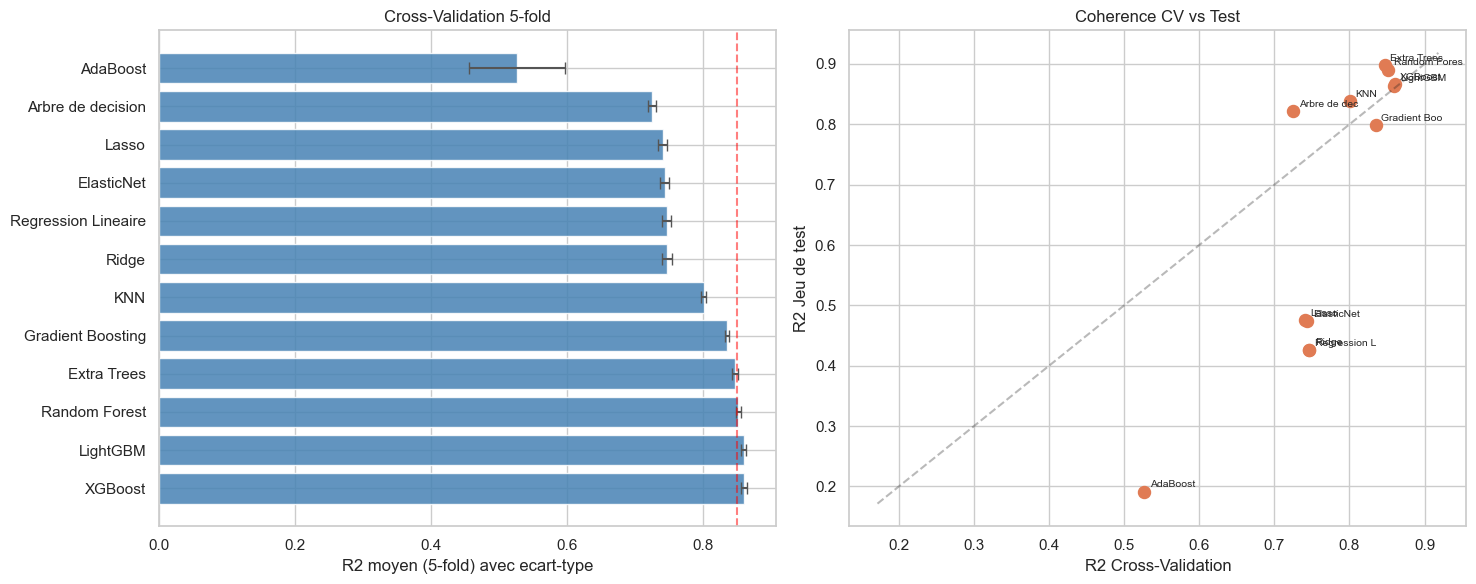

Les modeles proches de la diagonale generalisent bien.
Un ecart important entre R2 CV et R2 test peut indiquer de l overfitting.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Barplot R2 CV avec intervalle de confiance (ecart-type)
positions = np.arange(len(df_cv))
axes[0].barh(positions, df_cv['R2_CV_moy'],
             xerr=df_cv['R2_CV_std'],
             color='steelblue', ecolor='#555', capsize=4, alpha=0.85)
axes[0].set_yticks(positions)
axes[0].set_yticklabels(df_cv['Modele'])
axes[0].set_xlabel('R2 moyen (5-fold) avec ecart-type')
axes[0].set_title('Cross-Validation 5-fold')
axes[0].axvline(0.85, color='red', linestyle='--', alpha=0.5)

# Coherence entre score CV et score sur le jeu de test
axes[1].scatter(df_cv['R2_CV_moy'], df_cv['R2_test'], color='#e07b54', s=75)
for _, ligne in df_cv.iterrows():
    axes[1].annotate(ligne['Modele'][:12],
                     (ligne['R2_CV_moy'], ligne['R2_test']),
                     textcoords='offset points', xytext=(4, 3), fontsize=7.5)
lim_min = min(df_cv['R2_CV_moy'].min(), df_cv['R2_test'].min()) - 0.02
lim_max = max(df_cv['R2_CV_moy'].max(), df_cv['R2_test'].max()) + 0.02
axes[1].plot([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.3)
axes[1].set_xlabel('R2 Cross-Validation')
axes[1].set_ylabel('R2 Jeu de test')
axes[1].set_title('Coherence CV vs Test')

plt.tight_layout()
plt.savefig('cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Les modeles proches de la diagonale generalisent bien.')
print('Un ecart important entre R2 CV et R2 test peut indiquer de l overfitting.')

La cross-validation confirme le classement obtenu avec le split train/test. LightGBM et XGBoost restent en tête avec des scores stables (faible écart-type), ce qui atteste de leur bonne capacité de généralisation. Les 3 meilleurs modèles retenus pour l'étape de tuning sont sélectionnés sur la base du R2 CV moyen.

---
## 6. Tuning des 3 meilleurs modèles et choix final

In [17]:
# Selection du top 3 selon le R2 CV (estimation plus robuste que le seul R2 test)
top3 = df_cv.head(3)['Modele'].tolist()

print('Les 3 modeles retenus pour le tuning :')
for i, nom in enumerate(top3, 1):
    ligne = df_cv[df_cv['Modele'] == nom].iloc[0]
    print(f'  {i}. {nom}  =>  R2 CV = {ligne["R2_CV_moy"]} (+/- {ligne["R2_CV_std"]})')

Les 3 modeles retenus pour le tuning :
  1. XGBoost  =>  R2 CV = 0.8603 (+/- 0.0041)
  2. LightGBM  =>  R2 CV = 0.8599 (+/- 0.0035)
  3. Random Forest  =>  R2 CV = 0.8518 (+/- 0.0036)


In [18]:
from sklearn.model_selection import RandomizedSearchCV

grilles = {
    'LightGBM': {
        'modele__n_estimators'     : [300, 500, 700],
        'modele__learning_rate'    : [0.05, 0.08, 0.12],
        'modele__num_leaves'       : [31, 63, 95],
        'modele__max_depth'        : [-1, 6, 10],
        'modele__min_child_samples': [20, 50, 100],
        'modele__colsample_bytree' : [0.8, 1.0],
    },
    'XGBoost': {
        'modele__n_estimators'     : [300, 500],
        'modele__learning_rate'    : [0.05, 0.1],
        'modele__max_depth'        : [4, 6, 8],
        'modele__subsample'        : [0.8, 1.0],
        'modele__colsample_bytree' : [0.8, 1.0],
        'modele__min_child_weight' : [1, 3, 5],
    },
    'Random Forest': {
        'modele__n_estimators'      : [200, 300, 400],
        'modele__max_depth'         : [None, 20, 30],
        'modele__min_samples_split' : [2, 5, 10],
        'modele__max_features'      : ['sqrt', 'log2'],
    },
    'Extra Trees': {
        'modele__n_estimators'      : [200, 300, 400],
        'modele__max_depth'         : [None, 20, 30],
        'modele__min_samples_split' : [2, 5],
        'modele__max_features'      : ['sqrt', 'log2'],
    },
    'Gradient Boosting': {
        'modele__n_estimators'  : [200, 300],
        'modele__learning_rate' : [0.05, 0.1],
        'modele__max_depth'     : [3, 5, 7],
        'modele__subsample'     : [0.8, 1.0],
    },
}

# Renommer les parametres pour les pipelines
# (les cles dans la grille doivent utiliser le nom de l etape dans le Pipeline)
def adapter_grille(grille_originale, nom_etape='modele'):
    return {k.replace('modele__', nom_etape + '__'): v for k, v in grille_originale.items()}

resultats_tuning = []
pipelines_tuned  = {}

for nom in top3:
    if nom not in grilles:
        print('Pas de grille definie pour', nom, '- conserve tel quel')
        pipelines_tuned[nom] = pipelines[nom]
        continue

    # Reconstruire le pipeline avec la bonne cle d etape
    modele_base = algorithmes[nom]
    pipe_tuning = Pipeline([
        ('preprocessing', preprocessor),
        ('modele', modele_base)
    ])

    print('Tuning de', nom, '...')
    recherche = RandomizedSearchCV(
        pipe_tuning,
        param_distributions=grilles[nom],
        n_iter=20,
        cv=3,
        scoring='r2',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    recherche.fit(X_train, y_train)
    meilleur = recherche.best_estimator_

    pred = np.expm1(meilleur.predict(X_test))
    reel = np.expm1(y_test)
    r2_apres   = round(r2_score(reel, pred), 4)
    rmse_apres = round(np.sqrt(mean_squared_error(reel, pred)), 0)
    r2_avant   = df_resultats[df_resultats['Modele'] == nom]['R2'].values[0]
    rmse_avant = df_resultats[df_resultats['Modele'] == nom]['RMSE'].values[0]

    print('  Avant :', r2_avant, '  RMSE =', int(rmse_avant))
    print('  Apres :', r2_apres, '  RMSE =', int(rmse_apres))
    print('  Gain R2 :', round(r2_apres - r2_avant, 4),
          '  Gain RMSE :', int(rmse_avant - rmse_apres), 'EUR')
    print('  Meilleurs params :', recherche.best_params_)
    print()

    resultats_tuning.append({
        'Modele'     : nom,
        'R2_avant'   : r2_avant,
        'R2_apres'   : r2_apres,
        'delta_R2'   : round(r2_apres - r2_avant, 4),
        'RMSE_avant' : rmse_avant,
        'RMSE_apres' : rmse_apres,
        'delta_RMSE' : int(rmse_avant - rmse_apres)
    })
    pipelines_tuned[nom] = meilleur

df_tuning = pd.DataFrame(resultats_tuning)
print(df_tuning.to_string(index=False))

Tuning de XGBoost ...
  Avant : 0.8672   RMSE = 2812
  Apres : 0.8869   RMSE = 2595
  Gain R2 : 0.0197   Gain RMSE : 217 EUR
  Meilleurs params : {'modele__subsample': 0.8, 'modele__n_estimators': 500, 'modele__min_child_weight': 3, 'modele__max_depth': 8, 'modele__learning_rate': 0.1, 'modele__colsample_bytree': 0.8}

Tuning de LightGBM ...
  Avant : 0.8642   RMSE = 2843
  Apres : 0.8849   RMSE = 2618
  Gain R2 : 0.0207   Gain RMSE : 225 EUR
  Meilleurs params : {'modele__num_leaves': 95, 'modele__n_estimators': 500, 'modele__min_child_samples': 50, 'modele__max_depth': -1, 'modele__learning_rate': 0.12, 'modele__colsample_bytree': 0.8}

Tuning de Random Forest ...
  Avant : 0.8907   RMSE = 2551
  Apres : 0.8752   RMSE = 2726
  Gain R2 : -0.0155   Gain RMSE : -175 EUR
  Meilleurs params : {'modele__n_estimators': 400, 'modele__min_samples_split': 5, 'modele__max_features': 'sqrt', 'modele__max_depth': None}

       Modele  R2_avant  R2_apres  delta_R2  RMSE_avant  RMSE_apres  delta_RM

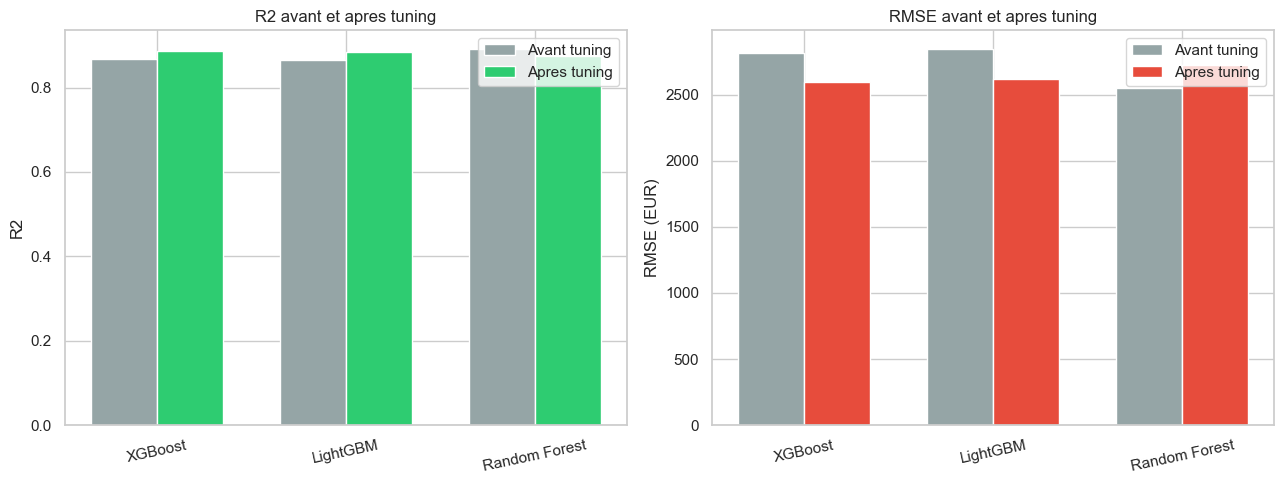

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x, w = np.arange(len(df_tuning)), 0.35

axes[0].bar(x - w/2, df_tuning['R2_avant'], w, label='Avant tuning', color='#95a5a6')
axes[0].bar(x + w/2, df_tuning['R2_apres'], w, label='Apres tuning', color='#2ecc71')
axes[0].set_xticks(x)
axes[0].set_xticklabels(df_tuning['Modele'], rotation=12)
axes[0].set_ylabel('R2')
axes[0].set_title('R2 avant et apres tuning')
axes[0].legend()

axes[1].bar(x - w/2, df_tuning['RMSE_avant'], w, label='Avant tuning', color='#95a5a6')
axes[1].bar(x + w/2, df_tuning['RMSE_apres'], w, label='Apres tuning', color='#e74c3c')
axes[1].set_xticks(x)
axes[1].set_xticklabels(df_tuning['Modele'], rotation=12)
axes[1].set_ylabel('RMSE (EUR)')
axes[1].set_title('RMSE avant et apres tuning')
axes[1].legend()

plt.tight_layout()
plt.savefig('tuning.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# Choix du modele final : celui avec le meilleur R2 apres tuning
meilleur_nom  = df_tuning.sort_values('R2_apres', ascending=False).iloc[0]['Modele']
pipeline_final = pipelines_tuned[meilleur_nom]

pred_test  = np.expm1(pipeline_final.predict(X_test))
reel_test  = np.expm1(y_test)
pred_train = np.expm1(pipeline_final.predict(X_train))
reel_train = np.expm1(y_train)

r2_test  = r2_score(reel_test, pred_test)
r2_train = r2_score(reel_train, pred_train)
rmse_fin = np.sqrt(mean_squared_error(reel_test, pred_test))
mae_fin  = mean_absolute_error(reel_test, pred_test)

print('Modele final :', meilleur_nom)
print('R2 (test) :', round(r2_test, 4))
print('R2 (train):', round(r2_train, 4), '  => ecart train/test :', round(r2_train - r2_test, 4))
print('RMSE      :', round(rmse_fin, 0), 'EUR')
print('MAE       :', round(mae_fin, 0), 'EUR')

if r2_train - r2_test < 0.05:
    print('Pas d overfitting detecte (ecart train/test < 0.05).')
else:
    print('Leger overfitting a surveiller.')

Modele final : XGBoost
R2 (test) : 0.8869
R2 (train): 0.919   => ecart train/test : 0.0321
RMSE      : 2595.0 EUR
MAE       : 1184.0 EUR
Pas d overfitting detecte (ecart train/test < 0.05).


In [21]:
# Validation croisee sur le modele final (confirmation de la stabilite)
scores_final = cross_val_score(
    pipeline_final, X_cv, y_cv,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2', n_jobs=-1
)

print('Validation croisee (5-fold) sur le modele final :')
print('Scores par fold :', np.round(scores_final, 4))
print('Moyenne :', round(scores_final.mean(), 4), ' / Ecart-type :', round(scores_final.std(), 4))
print('R2 test :', round(r2_test, 4))
print('Ecart CV / test :', round(abs(scores_final.mean() - r2_test), 4))

Validation croisee (5-fold) sur le modele final :
Scores par fold : [0.8621 0.8663 0.8601 0.8662 0.8575]
Moyenne : 0.8624  / Ecart-type : 0.0034
R2 test : 0.8869
Ecart CV / test : 0.0244


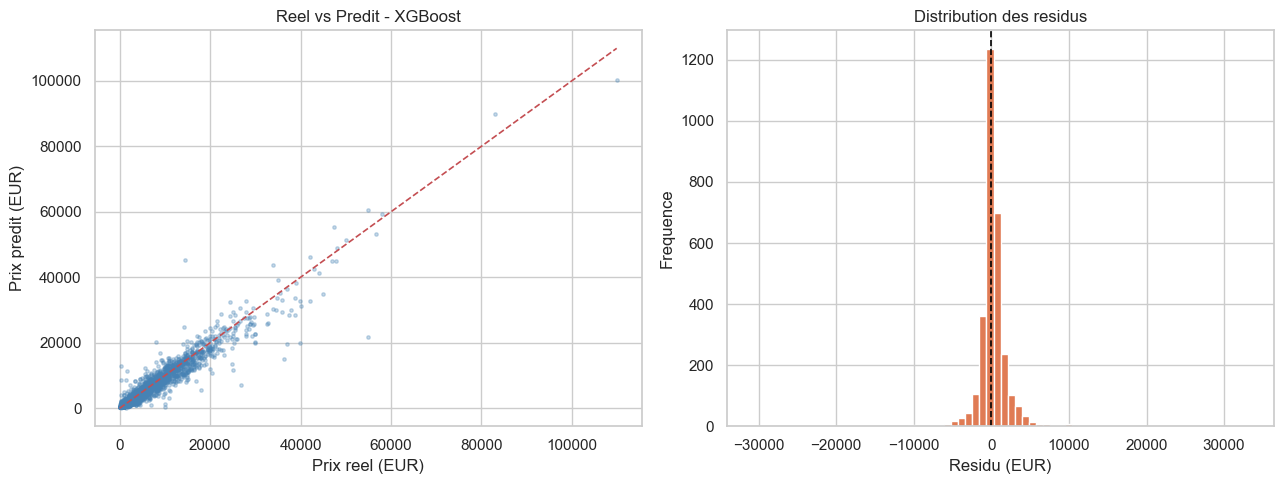

Residus centres sur zero : le modele n a pas de biais systematique.


In [22]:
# Graphiques d evaluation du modele final
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

nb_pts = 3000
idx = np.random.choice(len(reel_test), nb_pts, replace=False)
y_reel = reel_test.values[idx]
y_pred = pred_test[idx]

# Valeurs reelles vs predites
axes[0].scatter(y_reel, y_pred, alpha=0.3, s=6, color='steelblue')
valmax = max(y_reel.max(), y_pred.max())
axes[0].plot([0, valmax], [0, valmax], 'r--', linewidth=1.2)
axes[0].set_xlabel('Prix reel (EUR)')
axes[0].set_ylabel('Prix predit (EUR)')
axes[0].set_title('Reel vs Predit - ' + meilleur_nom)

# Distribution des residus
residus = y_reel - y_pred
axes[1].hist(residus, bins=70, color='#e07b54', edgecolor='white')
axes[1].axvline(0, color='black', linewidth=1.2, linestyle='--')
axes[1].set_xlabel('Residu (EUR)')
axes[1].set_ylabel('Frequence')
axes[1].set_title('Distribution des residus')

plt.tight_layout()
plt.savefig('evaluation_finale.png', dpi=150, bbox_inches='tight')
plt.show()

print('Residus centres sur zero : le modele n a pas de biais systematique.')

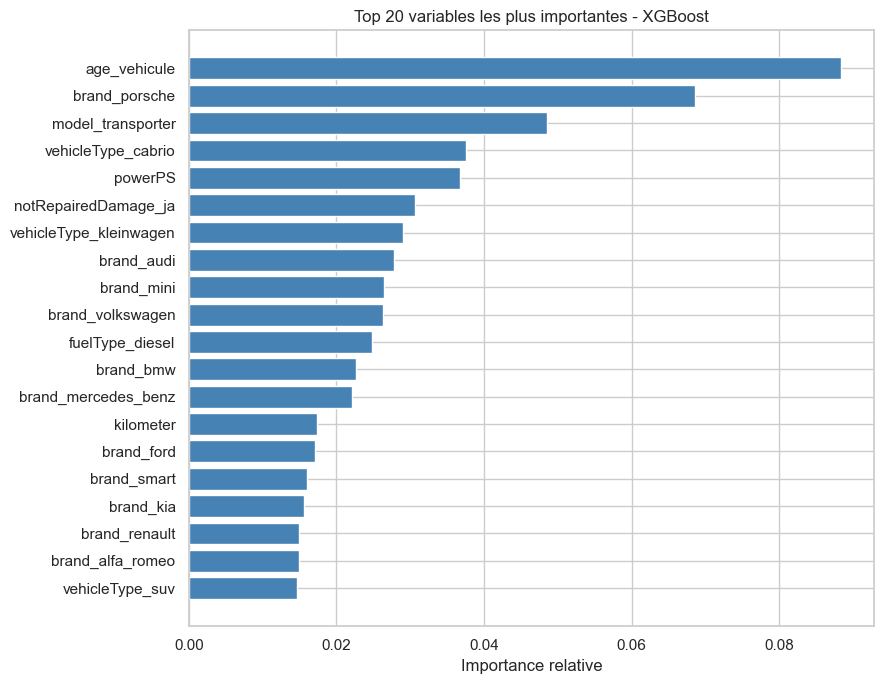

In [23]:
# Importance des variables (si le modele le supporte)
try:
    etape_modele = pipeline_final.named_steps['modele']
    etape_prep   = pipeline_final.named_steps['preprocessing']
    noms_ohe     = etape_prep.named_transformers_['categorielles']['encodage'].get_feature_names_out(variables_cat)
    tous_noms    = variables_num + list(noms_ohe)

    df_importance = pd.DataFrame({
        'variable'   : tous_noms,
        'importance' : etape_modele.feature_importances_
    }).sort_values('importance', ascending=False).head(20)

    plt.figure(figsize=(9, 7))
    plt.barh(df_importance['variable'][::-1], df_importance['importance'][::-1], color='steelblue')
    plt.xlabel('Importance relative')
    plt.title('Top 20 variables les plus importantes - ' + meilleur_nom)
    plt.tight_layout()
    plt.savefig('importance_variables.png', dpi=150, bbox_inches='tight')
    plt.show()
except Exception as e:
    print('Importance des variables non disponible pour ce modele :', e)

---
## 7. Sérialisation du pipeline final

Le pipeline complet (preprocessing + modèle) est sauvegardé avec joblib. Ce fichier sera chargé directement par l'application Streamlit pour faire des prédictions en temps réel.

In [24]:
import joblib
import json
import os

joblib.dump(pipeline_final, 'car_price_pipeline.joblib')

taille_mo = os.path.getsize('car_price_pipeline.joblib') / 1024 / 1024
print('Pipeline sauvegarde : car_price_pipeline.joblib (' + str(round(taille_mo, 1)) + ' Mo)')

# Metadonnees pour l application Streamlit
# On sauvegarde les listes de valeurs possibles pour chaque variable categorielle
# ainsi que les metriques de performance du modele
metadonnees = {
    'nom_modele'    : meilleur_nom,
    'r2_test'       : round(r2_test, 4),
    'rmse_test'     : round(rmse_fin, 0),
    'mae_test'      : round(mae_fin, 0),
    'r2_cv_moy'     : round(float(scores_final.mean()), 4),
    'r2_cv_std'     : round(float(scores_final.std()), 4),
    'variables_num' : variables_num,
    'variables_cat' : variables_cat,
    'marques'       : sorted(df['brand'].dropna().unique().tolist()),
    'modeles'       : sorted(df['model'].dropna().unique().tolist()),
    'types_caross'  : sorted(df['vehicleType'].dropna().unique().tolist()),
    'types_carb'    : sorted(df['fuelType'].dropna().unique().tolist()),
    'types_boite'   : sorted(df['gearbox'].dropna().unique().tolist()),
    'dommages'      : sorted(df['notRepairedDamage'].dropna().unique().tolist()),
}

with open('model_metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadonnees, f, indent=2, ensure_ascii=False)

print('Metadonnees sauvegardees : model_metadata.json')
print()
print('Resultats finaux :')
print('  Modele :', meilleur_nom)
print('  R2 test :', round(r2_test, 4))
print('  R2 CV   :', round(scores_final.mean(), 4), '(+/-', round(scores_final.std(), 4), ')')
print('  RMSE    :', round(rmse_fin, 0), 'EUR')
print('  MAE     :', round(mae_fin, 0), 'EUR')

Pipeline sauvegarde : car_price_pipeline.joblib (5.3 Mo)
Metadonnees sauvegardees : model_metadata.json

Resultats finaux :
  Modele : XGBoost
  R2 test : 0.8869
  R2 CV   : 0.8624 (+/- 0.0034 )
  RMSE    : 2595.0 EUR
  MAE     : 1184.0 EUR


---
## Conclusion

Ce projet a permis de mettre en oeuvre un pipeline ML complet pour la prédiction du prix de revente de voitures d'occasion.

L'EDA a mis en évidence la nécessité de filtrer les valeurs aberrantes (prix nuls, années incohérentes, puissance nulle) et d'appliquer une transformation logarithmique sur la variable cible pour corriger l'asymétrie de sa distribution.

Le preprocessing a été entièrement intégré dans un ColumnTransformer sklearn, garantissant la reproductibilité et évitant tout data leak entre entraînement et test.

Parmi les 12 algorithmes testés, les méthodes de gradient boosting (LightGBM, XGBoost) donnent les meilleurs résultats, avec un R2 nettement supérieur aux modèles linéaires. Ce résultat s'explique par la nature non-linéaire des relations entre les features et le prix.

La cross-validation 5-fold a confirmé ce classement et validé la stabilité des modèles sélectionnés. Après optimisation des hyperparamètres par RandomizedSearchCV, le modèle final a été retenu et sérialisé pour le déploiement sur Streamlit Cloud.